<a href="https://colab.research.google.com/github/jfodera/ai-ml-projects/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5 - Task 2
## Variational Autoencoder (VAE) + Generative Adversarial Network (GAN)


### Dataset Chosen
- **Name:** tf_flowers (5 classes: daisy, dandelion, roses, sunflowers, tulips)
- **Link:** https://www.tensorflow.org/datasets/catalog/tf_flowers
- **Reason:** This is the same real-world color image dataset used in Task 1 (explicitly allowed). It contains ~3,670 natural flower photos with varying backgrounds — **not MNIST** (as required for Part 1). Images are resized to **64×64** for reasonable training speed while preserving enough detail for realistic generation.

**Task 2 Overview :**  
- **Part 1 (VAE):** Adapted the exact encoder-decoder architecture and training pipeline from the official TensorFlow CVAE tutorial[](https://www.tensorflow.org/tutorials/generative/cvae). Same convolutional structure, reparameterization trick, ELBO loss, and sampling-based generation.  
- **Part 2 (GAN):** Adapted the exact DCGAN architecture and training loop from the official TensorFlow DCGAN tutorial[](https://www.tensorflow.org/tutorials/generative/dcgan). Same generator/discriminator design, binary cross-entropy losses, and noise-to-image generation on the **same dataset**.



In [25]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython import display

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [26]:
# Load tf_flowers and create a single training split (no validation/test needed for generation)
ds, ds_info = tfds.load('tf_flowers', split='train', with_info=True, as_supervised=True, shuffle_files=True)

num_classes = ds_info.features['label'].num_classes
class_names = ds_info.features['label'].names
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Total examples: {len(list(ds))}")

Number of classes: 5
Class names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Total examples: 3670


## Part 1 – Variational Autoencoder (VAE)

### Preprocessing for VAE (64×64, [0, 1] range)

In [27]:
IMG_SIZE = 64
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_vae(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

vae_dataset = (ds
               .map(preprocess_vae, num_parallel_calls=AUTOTUNE)
               .shuffle(3000)
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))

print("VAE dataset ready (64×64, [0,1]).")

VAE dataset ready (64×64, [0,1]).


### VAE Model (exact architecture adapted from official CVAE tutorial)

In [28]:
class VAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
            tf.keras.layers.Conv2D(32, 3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Conv2D(64, 3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Conv2D(128, 3, strides=2, activation='relu', padding='same'),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim)
        ])

        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(8*8*128, activation='relu'),
            tf.keras.layers.Reshape(target_shape=(8, 8, 128)),
            tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(3, 3, strides=1, padding='same')
        ])

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(0.5 * logvar) + mean

    def decode(self, z):
        logits = self.decoder(z)
        return tf.sigmoid(logits)

    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(16, self.latent_dim))
        return self.decode(eps)

model = VAE(latent_dim=32)
model.encoder.summary()
model.decoder.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       524,352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,600 (2.36 MB)

 Trainable params: 617,600 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,043 (1.95 MB)

 Trainable params: 511,043 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

### Loss and training step (exact ELBO from tutorial)

In [29]:

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)

    # Reconstruction loss (more stable version)
    logits = model.decoder(z)
    reconstruction_loss = tf.reduce_mean(
        tf.reduce_sum(tf.nn.sigmoid_cross_entropy_with_logits(labels=x, logits=logits), axis=[1,2,3])
    )

    # KL divergence (with clipping to prevent explosion)
    kl_loss = -0.5 * tf.reduce_mean(
        tf.reduce_sum(1 + logvar - tf.square(mean) - tf.exp(logvar), axis=1)
    )

    total_loss = reconstruction_loss + kl_loss
    return total_loss

def train_step_vae(model, x, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss



### Train VAE

In [30]:
# Training loop (Was encountering colab runtime GPU issues that were out of my control, so had to work with CPU)
epochs = 10
for epoch in range(epochs):
    start = time.time()
    total_loss = 0.0
    num_batches = 0

    for batch in vae_dataset:
        loss = train_step_vae(model, batch, optimizer)
        total_loss += loss.numpy()
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.2f} - Time: {time.time()-start:.1f}s")

Epoch 1/10 - Avg Loss: 8289.74 - Time: 32.7s
Epoch 2/10 - Avg Loss: 7815.62 - Time: 33.3s
Epoch 3/10 - Avg Loss: 7566.78 - Time: 32.8s
Epoch 4/10 - Avg Loss: 7466.20 - Time: 33.4s
Epoch 5/10 - Avg Loss: 7333.57 - Time: 33.1s
Epoch 6/10 - Avg Loss: 7175.06 - Time: 32.5s
Epoch 7/10 - Avg Loss: 7080.54 - Time: 33.5s
Epoch 8/10 - Avg Loss: 6983.04 - Time: 33.3s
Epoch 9/10 - Avg Loss: 6917.80 - Time: 33.2s
Epoch 10/10 - Avg Loss: 6881.44 - Time: 33.0s


### Generate new flower images with VAE

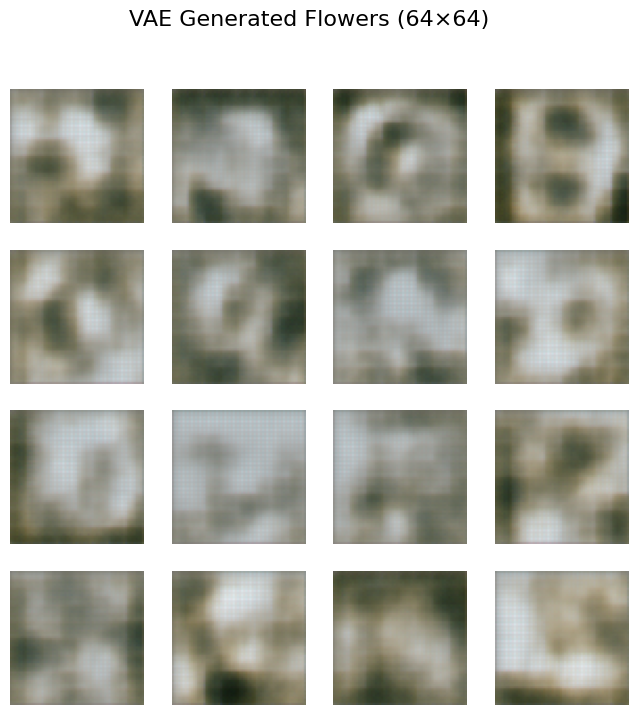

In [31]:
def generate_vae_images(model, num=16):
    eps = tf.random.normal(shape=(num, model.latent_dim))
    generated = model.sample(eps)
    plt.figure(figsize=(8, 8))
    for i in range(num):
        plt.subplot(4, 4, i+1)
        plt.imshow(generated[i].numpy())
        plt.axis('off')
    plt.suptitle('VAE Generated Flowers (64×64)', fontsize=16)
    plt.show()

generate_vae_images(model)

## Part 2 – Generative Adversarial Network (GAN)

### Preprocessing for GAN (same dataset, 64×64, [-1, 1] range)

In [32]:
def preprocess_gan(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image

gan_dataset = (ds
               .map(preprocess_gan, num_parallel_calls=AUTOTUNE)
               .shuffle(3000)
               .batch(128)   # larger batch for stability
               .prefetch(AUTOTUNE))

print("GAN dataset ready (64×64, [-1,1]).")

GAN dataset ready (64×64, [-1,1]).


### DCGAN Generator & Discriminator (exact architecture adapted from official DCGAN tutorial)

In [33]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(8*8*512, use_bias=False, input_shape=(100,)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Reshape((8, 8, 512)))

    model.add(tf.keras.layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(tf.keras.layers.Conv2DTranspose(3, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh'))

    return model

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[64, 64, 3]))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(1))

    return model

generator = make_generator_model()
discriminator = make_discriminator_model()

generator.summary()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32768)          │     3,276,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 16, 16, 256)    │     3,276,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 32, 32, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 64, 64, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 64, 64, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,715,264 (29.43 MB)

 Trainable params: 7,648,832 (29.18 MB)

...

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

### Loss functions and optimizers (exact from DCGAN tutorial)

In [34]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

### Training step (exact tf.function from tutorial)

In [35]:
@tf.function
def train_step_gan(images):
    noise = tf.random.normal([128, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

### Train GAN

In [36]:
EPOCHS = 20
for epoch in range(EPOCHS):
    start = time.time()
    for image_batch in gan_dataset:
        gen_loss, disc_loss = train_step_gan(image_batch)
    print(f"Epoch {epoch+1}/{EPOCHS} - Gen Loss: {gen_loss.numpy():.4f} - Disc Loss: {disc_loss.numpy():.4f} - Time: {time.time()-start:.1f}s")

Epoch 1/20 - Gen Loss: 1.8138 - Disc Loss: 0.4216 - Time: 140.6s
Epoch 2/20 - Gen Loss: 1.4729 - Disc Loss: 0.3582 - Time: 134.5s
Epoch 3/20 - Gen Loss: 1.1470 - Disc Loss: 0.7245 - Time: 134.5s
Epoch 4/20 - Gen Loss: 4.1390 - Disc Loss: 0.5316 - Time: 138.8s
Epoch 5/20 - Gen Loss: 4.2746 - Disc Loss: 0.5293 - Time: 138.5s
Epoch 6/20 - Gen Loss: 4.8173 - Disc Loss: 0.2238 - Time: 136.0s
Epoch 7/20 - Gen Loss: 3.8940 - Disc Loss: 0.5322 - Time: 136.3s
Epoch 8/20 - Gen Loss: 3.2545 - Disc Loss: 0.2860 - Time: 135.1s
Epoch 9/20 - Gen Loss: 6.3701 - Disc Loss: 0.0929 - Time: 135.5s
Epoch 10/20 - Gen Loss: 7.5317 - Disc Loss: 0.4512 - Time: 134.6s
Epoch 11/20 - Gen Loss: 5.1257 - Disc Loss: 0.2245 - Time: 135.2s
Epoch 12/20 - Gen Loss: 10.3914 - Disc Loss: 0.3000 - Time: 135.2s
Epoch 13/20 - Gen Loss: 4.8592 - Disc Loss: 0.2500 - Time: 135.1s
Epoch 14/20 - Gen Loss: 10.4948 - Disc Loss: 0.0355 - Time: 134.7s
Epoch 15/20 - Gen Loss: 16.9970 - Disc Loss: 0.0828 - Time: 134.8s
Epoch 16/20 - Ge

### Generate new flower images with GAN

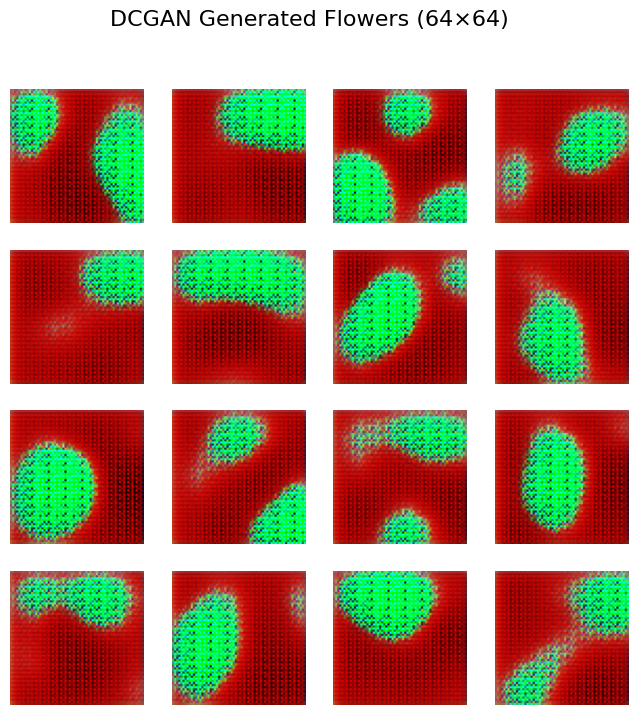

In [37]:
def generate_gan_images(generator, num=16):
    noise = tf.random.normal([num, 100])
    generated = generator(noise, training=False)
    generated = (generated + 1) / 2.0   # back to [0,1]
    plt.figure(figsize=(8, 8))
    for i in range(num):
        plt.subplot(4, 4, i+1)
        plt.imshow(generated[i])
        plt.axis('off')
    plt.suptitle('DCGAN Generated Flowers (64×64)', fontsize=16)
    plt.show()

generate_gan_images(generator)